<a href="https://colab.research.google.com/github/ranjetmahato416/-Lung-CT-Image-Classification-Using-Public-Medical-Imaging-Data-/blob/main/Notebook_08_Dataset_Quality_Validation_%26_Patient_Level_Splitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1. Project Overview

In [ ]:
# ============================================================
# Notebook 08
# Dataset Quality Validation & Patient-Level Splitting
# ============================================================

# This notebook performs:
#
# 1. Dataset validation
# 2. Duplicate detection
# 3. Image verification
# 4. Patient statistics
# 5. Dataset quality control
# 6. Patient-level train/validation/test split
#
# Input:
#    cnn_dataset.csv
#
# Output:
#    train.csv
#    validation.csv
#    test.csv
#
# ============================================================

##2. Mount Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


##3. Import Libraries

In [ ]:
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split

from PIL import Image

import hashlib

##4. Define Paths

In [ ]:
DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Dissertation"
)

PROCESSED_PATH = (
    DRIVE_ROOT /
    "Dataset" /
    "Processed"
)

CNN_PATH = (
    PROCESSED_PATH /
    "CNN_Dataset"
)

CSV_PATH = (
    PROCESSED_PATH /
    "cnn_dataset.csv"
)

print(CSV_PATH)

/content/drive/MyDrive/Dissertation/Dataset/Processed/cnn_dataset.csv


##5. Load Dataset

In [ ]:
dataset = pd.read_csv(CSV_PATH)

print("Dataset shape:")

print(dataset.shape)

print()

dataset.head()

Dataset shape:
(145, 5)



,PatientID,NoduleID,CancerLabel,LabelName,ImagePath
0,LIDC-IDRI-0001,1,1,Malignant,/content/drive/MyDrive/Dissertation/Dataset/Pr...
1,LIDC-IDRI-0002,1,1,Malignant,/content/drive/MyDrive/Dissertation/Dataset/Pr...
2,LIDC-IDRI-0003,1,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...
3,LIDC-IDRI-0003,2,1,Malignant,/content/drive/MyDrive/Dissertation/Dataset/Pr...
4,LIDC-IDRI-0003,3,0,Benign,/content/drive/MyDrive/Dissertation/Dataset/Pr...


##6. Check Missing Values

In [ ]:
print("Missing values")

print()

print(dataset.isnull().sum())

Missing values

PatientID      0
NoduleID       0
CancerLabel    0
LabelName      0
ImagePath      0
dtype: int64


##7. Dataset Summary

In [ ]:
print("=" * 60)

print("DATASET SUMMARY")

print("=" * 60)

print()

print("Patients:")

print(dataset.PatientID.nunique())

print()

print("Images:")

print(len(dataset))

print()

print("Class Distribution")

print(dataset.LabelName.value_counts())

print()

print("Cancer Labels")

print(dataset.CancerLabel.value_counts())

DATASET SUMMARY

Patients:
47

Images:
145

Class Distribution
LabelName
Benign       122
Malignant     23
Name: count, dtype: int64

Cancer Labels
CancerLabel
0    122
1     23
Name: count, dtype: int64


##8. Verify Image Files

In [ ]:
# ============================================================
# Section 8 - Verify Image Files
# ============================================================

missing = []
corrupted = []

for path in tqdm(dataset["ImagePath"], desc="Checking images"):

    path = Path(path)

    if not path.exists():
        missing.append(str(path))
        continue

    img = cv2.imread(str(path))

    if img is None:
        corrupted.append(str(path))


print("="*60)

print("Missing images :", len(missing))
print("Corrupted images:", len(corrupted))

Checking images: 100%|██████████| 145/145 [00:42<00:00,  3.41it/s]

Missing images : 0
Corrupted images: 0


##9. Duplicate Patient-Nodule Check

In [ ]:
# ============================================================
# Section 9 - Duplicate Nodule Check
# ============================================================

duplicates = dataset.duplicated(
    subset=["PatientID", "NoduleID"]
)

print("Duplicate nodules:", duplicates.sum())

if duplicates.sum() > 0:
    display(dataset[duplicates])

Duplicate nodules: 1


,PatientID,NoduleID,CancerLabel,LabelName,ImagePath
144,LIDC-IDRI-0050,1,1,Malignant,/content/drive/MyDrive/Dissertation/Dataset/Pr...


##10. Duplicate Image Detection

In [ ]:
# ============================================================
# Section 10 - Duplicate Image Detection
# ============================================================

def file_hash(path):

    with open(path, "rb") as f:
        return hashlib.sha256(
            f.read()
        ).hexdigest()


hashes = {}

duplicates = []

for path in tqdm(dataset["ImagePath"], desc="Hashing images"):

    h = file_hash(path)

    if h in hashes:

        duplicates.append(
            (
                hashes[h],
                path
            )
        )

    else:

        hashes[h] = path


print("Duplicate images:", len(duplicates))

Hashing images: 100%|██████████| 145/145 [00:00<00:00, 377.12it/s]

Duplicate images: 1


##11. Image Statistics

In [ ]:
# ============================================================
# Section 11 - Dataset Image Statistics
# ============================================================

means = []
stds = []

mins = []
maxs = []

for path in tqdm(dataset["ImagePath"], desc="Statistics"):

    img = cv2.imread(str(path))

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    means.append(img.mean())

    stds.append(img.std())

    mins.append(img.min())

    maxs.append(img.max())


print("="*60)

print("Mean intensity : %.2f" % np.mean(means))

print("Std intensity  : %.2f" % np.mean(stds))

print("Minimum pixel  :", np.min(mins))

print("Maximum pixel  :", np.max(maxs))

Statistics: 100%|██████████| 145/145 [00:00<00:00, 158.63it/s]

Mean intensity : 101.57
Std intensity  : 69.84
Minimum pixel  : 0
Maximum pixel  : 255


##12. Patient Distribution

In [ ]:
# ============================================================
# Section 12 - Nodules Per Patient
# ============================================================

patient_counts = (
    dataset
    .groupby("PatientID")
    .size()
    .sort_values(ascending=False)
)

print(patient_counts.head(20))

PatientID
LIDC-IDRI-0049    14
LIDC-IDRI-0045    12
LIDC-IDRI-0012    10
LIDC-IDRI-0042     8
LIDC-IDRI-0027     6
LIDC-IDRI-0011     6
LIDC-IDRI-0039     5
LIDC-IDRI-0016     5
LIDC-IDRI-0046     5
LIDC-IDRI-0018     4
LIDC-IDRI-0003     4
LIDC-IDRI-0006     4
LIDC-IDRI-0044     4
LIDC-IDRI-0005     3
LIDC-IDRI-0013     3
LIDC-IDRI-0024     3
LIDC-IDRI-0048     3
LIDC-IDRI-0043     3
LIDC-IDRI-0021     3
LIDC-IDRI-0031     3
dtype: int64


####Visualize

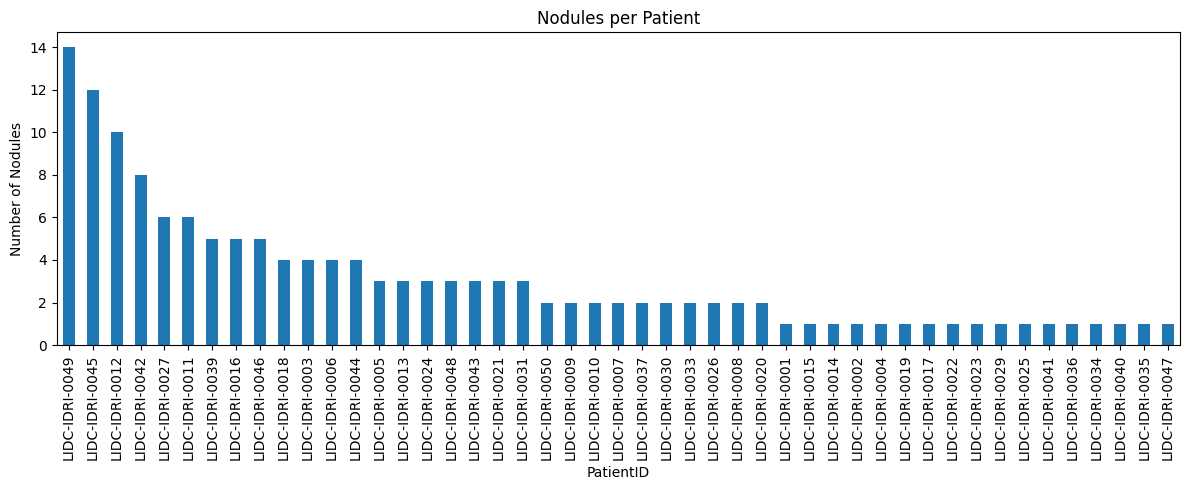

In [ ]:
plt.figure(figsize=(12,5))

patient_counts.plot(kind="bar")

plt.ylabel("Number of Nodules")

plt.title("Nodules per Patient")

plt.tight_layout()

plt.show()

##13. Image Size Verification

In [ ]:
# ============================================================
# Section 13 - Verify Image Size
# ============================================================

sizes = []

for path in dataset["ImagePath"]:

    img = cv2.imread(path)

    sizes.append(img.shape)

sizes = np.array(sizes)

unique_sizes = np.unique(sizes, axis=0)

print(unique_sizes)

[[128 128   3]]


##14. Investigate the Duplicate

In [ ]:
# ============================================================
# Section 14 - Investigate Duplicate Nodule
# ============================================================

duplicates = dataset[
    dataset.duplicated(
        subset=["PatientID", "NoduleID"],
        keep=False
    )
]

duplicates.sort_values(
    ["PatientID", "NoduleID"]
)

,PatientID,NoduleID,CancerLabel,LabelName,ImagePath
143,LIDC-IDRI-0050,1,1,Malignant,/content/drive/MyDrive/Dissertation/Dataset/Pr...
144,LIDC-IDRI-0050,1,1,Malignant,/content/drive/MyDrive/Dissertation/Dataset/Pr...


##15. Compare the Two Images

In [ ]:
dup = duplicates.reset_index(drop=True)

img1 = cv2.imread(dup.loc[0, "ImagePath"])
img2 = cv2.imread(dup.loc[1, "ImagePath"])

print(np.array_equal(img1, img2))

True


##16. Display Both Images

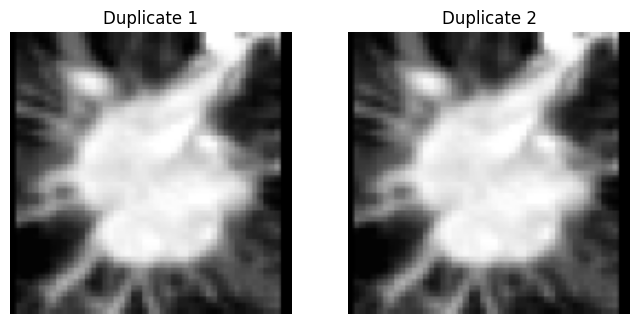

In [ ]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Duplicate 1")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title("Duplicate 2")
plt.axis("off")

plt.show()

####Remove Duplicate

In [ ]:
dataset = dataset.drop_duplicates(
    subset=["PatientID", "NoduleID"]
).reset_index(drop=True)

print(dataset.shape)

(144, 5)


####Save the Clean Dataset

In [ ]:
dataset.to_csv(
    CSV_PATH,
    index=False
)

print("Dataset updated.")

Dataset updated.


##18. Patient-Level Spli

In [ ]:
# ============================================================
# Section 17 - Patient-Level Split
# ============================================================

patients = sorted(
    dataset["PatientID"].unique()
)

print("Patients:", len(patients))

Patients: 47


In [ ]:
train_patients, temp_patients = train_test_split(
    patients,
    test_size=0.30,
    random_state=42
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=42
)

print("Train:", len(train_patients))
print("Validation:", len(val_patients))
print("Test:", len(test_patients))

Train: 32
Validation: 7
Test: 8


##18. Build the Three Datasets

In [ ]:
train_df = dataset[
    dataset.PatientID.isin(train_patients)
].reset_index(drop=True)

validation_df = dataset[
    dataset.PatientID.isin(val_patients)
].reset_index(drop=True)

test_df = dataset[
    dataset.PatientID.isin(test_patients)
].reset_index(drop=True)

print(train_df.shape)
print(validation_df.shape)
print(test_df.shape)

(111, 5)
(12, 5)
(21, 5)


##19. Verify No Patient Leakage

In [ ]:
train_ids = set(train_df.PatientID)
val_ids = set(validation_df.PatientID)
test_ids = set(test_df.PatientID)

print("Train ∩ Validation:", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Validation ∩ Test:", len(val_ids & test_ids))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


##20. Class Distribution Across Splits

In [ ]:
# ============================================================
# Section 20 - Class Distribution
# ============================================================

print("=" * 60)

print("TRAIN")

print(train_df["LabelName"].value_counts())

print()

print("VALIDATION")

print(validation_df["LabelName"].value_counts())

print()

print("TEST")

print(test_df["LabelName"].value_counts())

TRAIN
LabelName
Benign       97
Malignant    14
Name: count, dtype: int64

VALIDATION
LabelName
Benign       7
Malignant    5
Name: count, dtype: int64

TEST
LabelName
Benign       18
Malignant     3
Name: count, dtype: int64


####Visualization

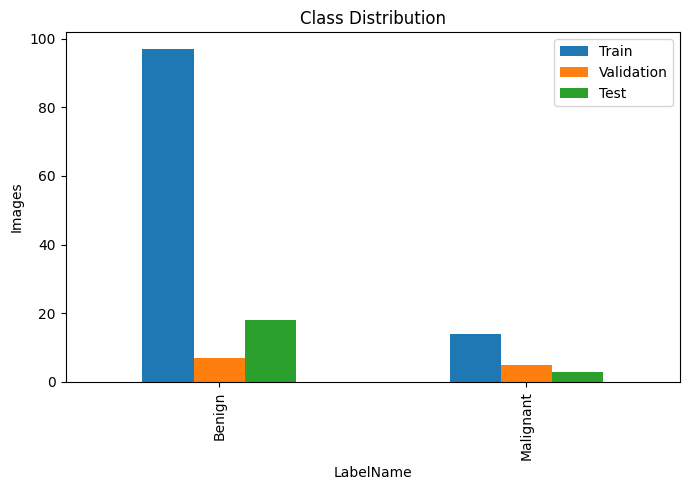

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))

summary = pd.DataFrame({
    "Train": train_df["LabelName"].value_counts(),
    "Validation": validation_df["LabelName"].value_counts(),
    "Test": test_df["LabelName"].value_counts()
}).fillna(0)

summary.plot(kind="bar", ax=ax)

plt.ylabel("Images")

plt.title("Class Distribution")

plt.tight_layout()

plt.show()

##21. Save the Splits

In [ ]:
# ============================================================
# Section 21 - Save CSV Files
# ============================================================

train_csv = PROCESSED_PATH / "train.csv"

validation_csv = PROCESSED_PATH / "validation.csv"

test_csv = PROCESSED_PATH / "test.csv"


train_df.to_csv(train_csv, index=False)

validation_df.to_csv(validation_csv, index=False)

test_df.to_csv(test_csv, index=False)


print(train_csv)

print(validation_csv)

print(test_csv)

/content/drive/MyDrive/Dissertation/Dataset/Processed/train.csv
/content/drive/MyDrive/Dissertation/Dataset/Processed/validation.csv
/content/drive/MyDrive/Dissertation/Dataset/Processed/test.csv


##22. Verify Saved Files

In [ ]:
train = pd.read_csv(train_csv)

val = pd.read_csv(validation_csv)

test = pd.read_csv(test_csv)


print("Train:", train.shape)

print("Validation:", val.shape)

print("Test:", test.shape)

Train: (111, 5)
Validation: (12, 5)
Test: (21, 5)


##23. Final Dataset Report

In [ ]:
# ============================================================
# Section 23 - Final Dataset Report
# ============================================================

print("="*60)

print("FINAL DATASET REPORT")

print("="*60)

print()

print("Patients")

print(dataset.PatientID.nunique())

print()

print("Images")

print(len(dataset))

print()

print("Train")

print(len(train))

print()

print("Validation")

print(len(val))

print()

print("Test")

print(len(test))

print()

print("Benign")

print(dataset.LabelName.value_counts()["Benign"])

print()

print("Malignant")

print(dataset.LabelName.value_counts()["Malignant"])

FINAL DATASET REPORT

Patients
47

Images
144

Train
111

Validation
12

Test
21

Benign
122

Malignant
22


##24. Final Random Quality Check

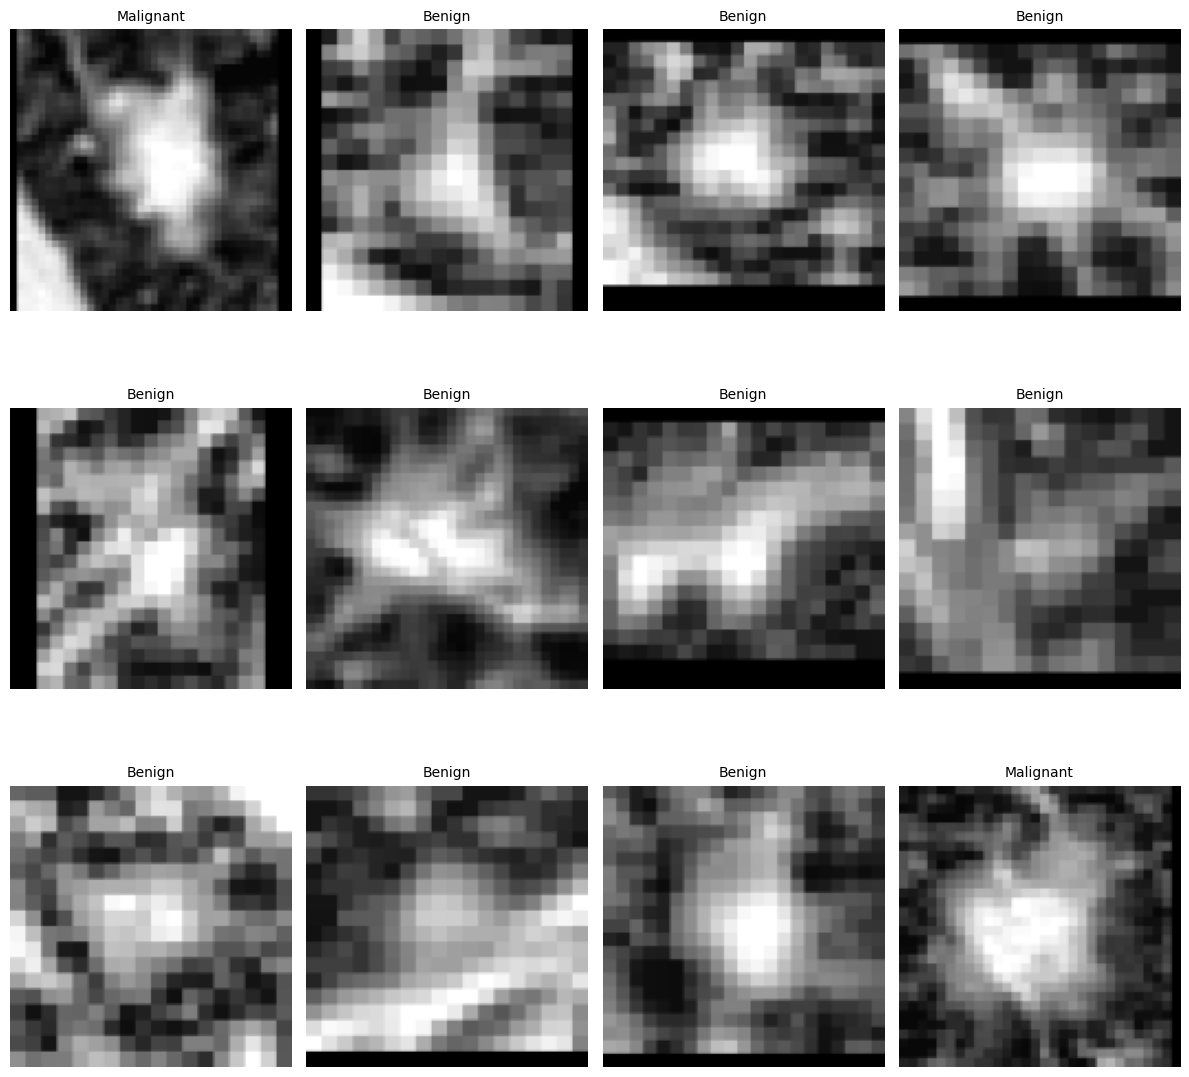

In [ ]:
# ============================================================
# Section 24 - Random Image Verification
# ============================================================

samples = dataset.sample(12, random_state=42)

plt.figure(figsize=(12,12))

for i, (_, row) in enumerate(samples.iterrows()):

    img = cv2.imread(row["ImagePath"])

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,4,i+1)

    plt.imshow(img)

    plt.title(row["LabelName"], fontsize=10)

    plt.axis("off")

plt.tight_layout()

plt.show()